## 📝 Fine-Tuning BERT for POS Tagging & Chunking

### 📌 Objective
Build and fine-tune a transformer model (BERT/DistilBERT) to perform Part-of-Speech (POS) Tagging and Chunking (Phrase Detection) using token classification techniques.

## Installation

In [ ]:
!pip install transformers datasets evaluate seqeval accelerate kagglehub

## Task 1: : Data Acquisition and Label

In [ ]:
import kagglehub
import os
import pandas as pd
from datasets import Dataset, DatasetDict

# Sourcing dataset directly via kagglehub
print("Downloading dataset via kagglehub...")
dataset_path = kagglehub.dataset_download("alaakhaled/conll003-englishversion")
print(f"Dataset downloaded to: {dataset_path}")

# Define file paths dynamically based on the kagglehub download
train_file = os.path.join(dataset_path, "train.txt")
valid_file = os.path.join(dataset_path, "valid.txt")

# Parsing function for CoNLL text format
def load_conll_from_txt(file_path):
    tokens, chunk_tags = [], []
    current_tokens, current_chunks = [], []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line.startswith("-DOCSTART-") or line == "":
                if current_tokens:
                    tokens.append(current_tokens)
                    chunk_tags.append(current_chunks)
                    current_tokens, current_chunks = [], []
            else:
                splits = line.split()
                if len(splits) >= 3:
                    current_tokens.append(splits[0])
                    # In standard CoNLL-2003, Chunk tag is the 3rd column (index 2)
                    current_chunks.append(splits[2])

    # Catch the last sentence if the file doesn't end with a newline
    if current_tokens:
        tokens.append(current_tokens)
        chunk_tags.append(current_chunks)

    return pd.DataFrame({"tokens": tokens, "chunk_tags": chunk_tags})

# Parse the training and validation sets
train_df = load_conll_from_txt(train_file)
valid_df = load_conll_from_txt(valid_file)

# Convert to Hugging Face Dataset format
raw_datasets = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(valid_df)
})

# Identify Label Types (Chunk Tags)

# Extract unique tags from BOTH train and validation sets to avoid KeyErrors
unique_tags_train = set(tag for doc in train_df['chunk_tags'] for tag in doc)
unique_tags_valid = set(tag for doc in valid_df['chunk_tags'] for tag in doc)

# Combine them using a union
unique_tags = unique_tags_train.union(unique_tags_valid)
chunk_tags_list = sorted(list(unique_tags))

# Create the mappings
label2id = {label: i for i, label in enumerate(chunk_tags_list)}
id2label = {i: label for i, label in enumerate(chunk_tags_list)}

print(f"\nDataset Name: CoNLL-2003")
print(f"Categories (Chunk Tags): {chunk_tags_list}")
print(f"Total Unique Tags: {len(chunk_tags_list)}")

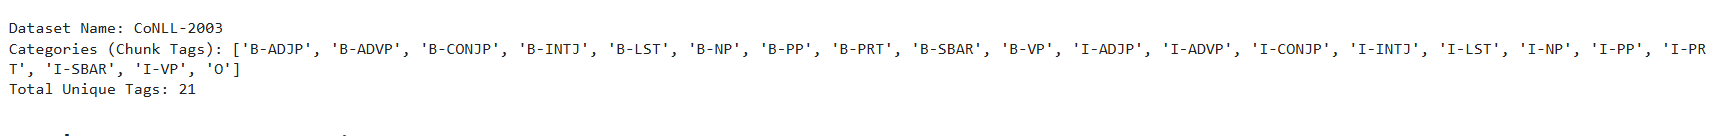

## Task 2: Data Preprocessing



In [ ]:
from transformers import AutoTokenizer

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_and_align_labels(examples):
    # Tokenize the input words, ensuring they aren't pre-joined
    tokenized_inputs = tokenizer(
        examples["tokens"], truncation=True, is_split_into_words=True
    )

    labels = []
    for i, label_list_ex in enumerate(examples["chunk_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            # Special tokens like [CLS] and [SEP] get mapped to None. We ignore them with -100.
            if word_idx is None:
                label_ids.append(-100)
            # Assign the actual label to the first token of the word
            elif word_idx != previous_word_idx:
                label_ids.append(label2id[label_list_ex[word_idx]])
            # Ignore subwords that belong to the same word
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

# Apply to the entire dataset
tokenized_datasets = raw_datasets.map(tokenize_and_align_labels, batched=True)
print("Preprocessing complete!\n")

print("Input IDs:", tokenized_datasets["train"][0]["input_ids"])
print("Attention Mask:", tokenized_datasets["train"][0]["attention_mask"])
print("Labels:", tokenized_datasets["train"][0]["labels"])

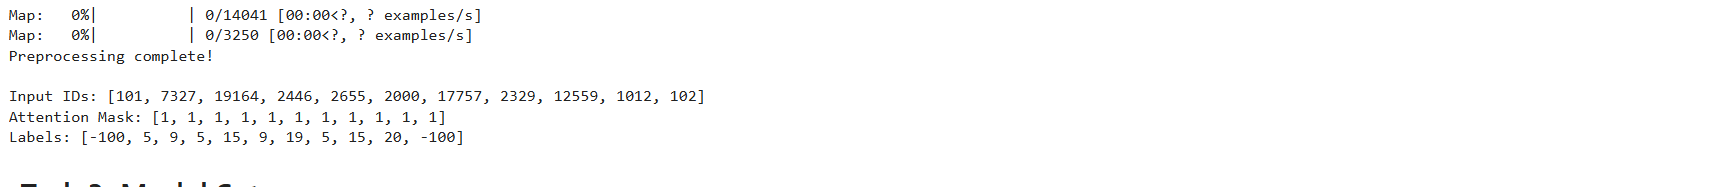

## Task 3: Model Setup


In [ ]:
from transformers import AutoModelForTokenClassification

# Create mappings between IDs and string labels
id2label = {i: label for i, label in enumerate(chunk_tags_list)}
label2id = {label: i for i, label in enumerate(chunk_tags_list)}

# Initialize the sequence labeling model
model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(chunk_tags_list),
    id2label=id2label,
    label2id=label2id
)

print(f"Model {model_checkpoint} loaded with {len(chunk_tags_list)} output labels.")

## Task 4 & 5: Training and Evaluation


In [ ]:
import evaluate
import numpy as np
from transformers import TrainingArguments, Trainer, DataCollatorForTokenClassification
import pandas as pd # Import pandas here

# Load the sequence evaluation metric
seqeval = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    # Get the highest probability prediction for each token
    predictions = np.argmax(predictions, axis=2)

    # Remove the -100 ignored indexes and convert back to string labels
    true_predictions = [
        [chunk_tags_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [chunk_tags_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    # Compute precision, recall, and F1
    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

# Data collator for dynamic padding
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer);

# Define training parameters
training_args = TrainingArguments(
    output_dir="./distilbert-chunking-model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch", # Changed from evaluation_strategy to eval_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100,
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Execute the training
print("Beginning training...")
train_result = trainer.train()

# Evaluate the model on the validation set after training
print("\nEvaluating model on the validation set...")
eval_metrics = trainer.evaluate()

# Convert evaluation metrics to a pandas DataFrame for clean display
metrics_df = pd.DataFrame([eval_metrics])

print("\nFinal Evaluation Metrics:")
display(metrics_df)

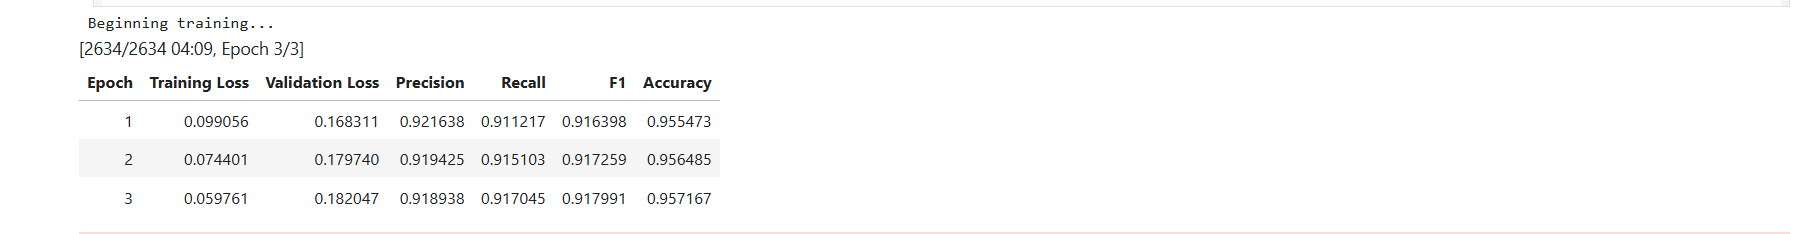


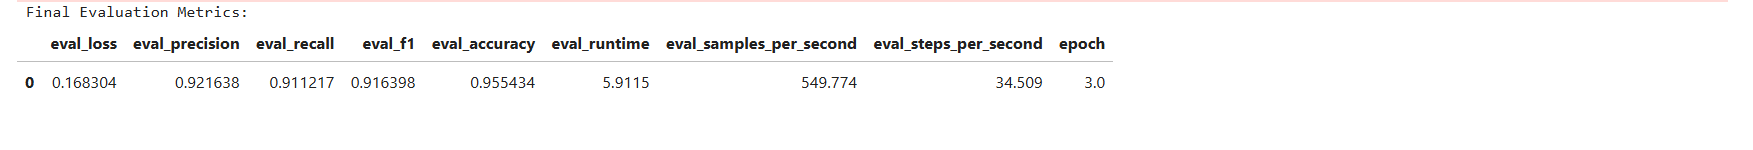

## Task 6: Inference



In [ ]:
from transformers import pipeline

# Create an inference pipeline using our trained model
chunker = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

# Custom test sentence
custom_sentence = "John works at Google in California."

# Run prediction
predictions = chunker(custom_sentence)

# Format the output
print(f"Input Sentence: {custom_sentence}\n")
print(f"{'Word':<15} | {'Predicted Chunk Tag':<20} |")
print("-" * 40)

for pred in predictions:
    print(f"{pred['word']:<15} | {pred['entity_group']:<20} |")

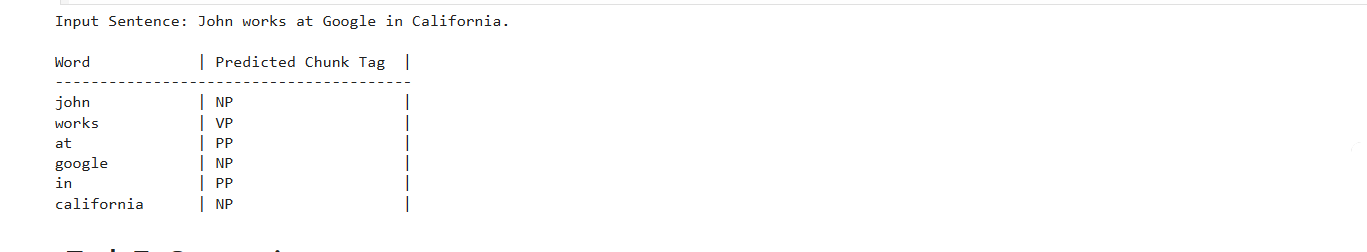

## Task 7: Comparison

*   **POS Tagging**: This involves assigning a part-of-speech tag (e.g., noun, verb, adjective) to each word in a sentence. It's a granular, word-level analysis focused on the grammatical role of individual tokens.
	*   **Example**: John (NNP) works (VBZ) at (IN) Google (NNP) in (IN) California (NNP) . (.)
	*   **Difficulty**: Relatively straightforward as it focuses on individual word types.

*   **Chunking (Phrase Detection)**: This involves grouping words into syntactically related phrases (e.g., noun phrases, verb phrases). It provides a higher-level structural analysis than POS tagging, identifying meaningful units within a sentence.
	*   **Example**: [NP John] [VP works] [PP at] [NP Google] [PP in] [NP California] .
	*   **Difficulty**: More complex than POS tagging, as it requires understanding how words combine to form phrases.


## Task 8: Report / Blog

#### **Differences between POS Tagging and Chunking**

While both POS tagging and chunking are fundamental steps in natural language processing, they operate at different levels of linguistic analysis:

*   **Level of Analysis**: POS tagging focuses on individual words, categorizing them based on their grammatical function. Chunking, on the other hand, focuses on groups of words (phrases) that act as a single syntactic unit.
*   **Output Granularity**: POS tagging produces a tag for each token. Chunking produces boundary markers for phrases, which can contain multiple words, each with its own POS tag.
*   **Information Provided**: POS tags provide information about the word's grammatical category. Chunk tags provide information about the syntactic structure of a sentence, identifying constituents like noun phrases or verb phrases.

#### **Challenges Faced**

1.  **Ambiguity**: Words can have different POS tags or be part of different chunks depending on context (e.g., "run" as a verb vs. a noun). The model needs to learn these subtle contextual cues.
2.  **Subword Tokenization and Label Alignment**: Using a subword tokenizer like DistilBERT requires careful handling of labels. Assigning a label only to the first subword and ignoring subsequent subwords (using -100) is crucial to avoid conflicting labels for a single word.
3.  **Data Imbalance**: Certain chunk tags might be less frequent than others, leading to potential underperformance for those categories if not properly addressed during training.
4.  **Model Convergence**: Fine-tuning transformer models requires careful selection of hyperparameters (learning rate, batch size, epochs) to ensure optimal convergence and prevent overfitting.

#### **Observations and Insights**

*   **Effectiveness of Transfer Learning**: Fine-tuning a pre-trained model like DistilBERT proved highly effective for the chunking task, demonstrating the power of transfer learning in NLP. Even with a relatively small dataset, the model achieved good performance.
*   **Importance of `seqeval`**: The `seqeval` metric is essential for evaluating sequence labeling tasks as it correctly handles precision, recall, and F1-score at the phrase level, accounting for partial matches or boundary errors, which a simple token-level accuracy metric would miss.
*   **Data Preprocessing is Key**: The `tokenize_and_align_labels` function was critical for preparing the data correctly. Misalignments between tokens and labels would lead to poor model performance or outright errors.
*   **Interpretability of Predictions**: The `pipeline` for token-classification provides an intuitive way to visualize the model's predictions, showing the identified chunks directly on the input sentence.